# Phase 2 — Notebook 2: Evaluation and Comparison of All 3 Models

**Dataset:** Healthcare Stroke Prediction  
**Authors:** Bora   
**Course:** Machine Learning — UNYT, 2026

This notebook evaluates and compares the three classification models used in Phase 2:
- Logistic Regression
- Support Vector Machine (SVM)
- XGBoost

## Goals
- Load the processed dataset from Phase 1
- Train and tune all three models
- Evaluate them on the same test set
- Compare metrics, ROC curves, confusion matrices, and training time
- Identify the strongest final model

In [1]:
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, classification_report, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder, StandardScaler

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

try:
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True
except ImportError:
    IMBLEARN_AVAILABLE = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

RANDOM_STATE = 42
print("Libraries imported successfully.")
if not XGBOOST_AVAILABLE:
    print("xgboost is not installed. Install it with: pip install xgboost")

Libraries imported successfully.
xgboost is not installed. Install it with: pip install xgboost


## 1. Load Preprocessed Data

This notebook first looks for the saved outputs from preprocessing.
If they are unavailable, it rebuilds the dataset using the same logic as the Phase 2 script.

In [2]:
output_dir = None
for candidate in [Path("../outputs"), Path("outputs")]:
    if (candidate / "X_train.csv").exists():
        output_dir = candidate
        break

def load_phase1_outputs():
    X_train = pd.read_csv(output_dir / "X_train.csv")
    X_test = pd.read_csv(output_dir / "X_test.csv")
    y_train = pd.read_csv(output_dir / "y_train.csv").squeeze("columns")
    y_test = pd.read_csv(output_dir / "y_test.csv").squeeze("columns")

    X_train_smote_path = output_dir / "X_train_smote.csv"
    y_train_smote_path = output_dir / "y_train_smote.csv"

    if X_train_smote_path.exists() and y_train_smote_path.exists():
        X_train_smote = pd.read_csv(X_train_smote_path)
        y_train_smote = pd.read_csv(y_train_smote_path).squeeze("columns")
    else:
        X_train_smote, y_train_smote = None, None

    return X_train, X_test, y_train, y_test, X_train_smote, y_train_smote

def rebuild_from_raw():
    raw_candidates = [
        Path("../data/healthcare-dataset-stroke-data.csv"),
        Path("data/healthcare-dataset-stroke-data.csv"),
        Path("healthcare-dataset-stroke-data.csv"),
    ]

    raw_path = None
    for candidate in raw_candidates:
        if candidate.exists():
            raw_path = candidate
            break

    if raw_path is None:
        raise FileNotFoundError(
            "Could not find Phase 1 outputs or the raw dataset. "
            "Please place the dataset in a data folder or run preprocessing first."
        )

    df = pd.read_csv(raw_path)
    df["bmi"] = pd.to_numeric(df["bmi"], errors="coerce")
    if "id" in df.columns:
        df = df.drop(columns=["id"])
    df = df[df["gender"] != "Other"].copy()

    le = LabelEncoder()
    for col in ["gender", "ever_married", "Residence_type"]:
        df[col] = le.fit_transform(df[col])

    df = pd.get_dummies(df, columns=["work_type", "smoking_status"], drop_first=False)

    target = "stroke"
    numerical_features = ["age", "avg_glucose_level", "bmi"]

    X = df.drop(columns=[target])
    y = df[target]

    X["bmi"] = X["bmi"].fillna(X["bmi"].median())

    scaler = StandardScaler()
    X_scaled = X.copy()
    X_scaled[numerical_features] = scaler.fit_transform(X[numerical_features])

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )

    if IMBLEARN_AVAILABLE:
        smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
        X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
        X_train_smote = pd.DataFrame(X_train_smote, columns=X_train.columns)
        y_train_smote = pd.Series(y_train_smote, name="stroke")
    else:
        X_train_smote, y_train_smote = None, None

    return X_train, X_test, y_train, y_test, X_train_smote, y_train_smote

if output_dir is not None:
    X_train, X_test, y_train, y_test, X_train_smote, y_train_smote = load_phase1_outputs()
    print(f"Loaded Phase 1 outputs from: {output_dir.resolve()}")
else:
    X_train, X_test, y_train, y_test, X_train_smote, y_train_smote = rebuild_from_raw()
    print("Phase 1 outputs not found, so preprocessing was rebuilt from raw data.")

if X_train_smote is not None and y_train_smote is not None:
    X_fit = X_train_smote.copy()
    y_fit = y_train_smote.copy()
    print("Using SMOTE-balanced training data.")
else:
    X_fit = X_train.copy()
    y_fit = y_train.copy()
    print("Using original training data.")

print("X_fit :", X_fit.shape)
print("X_test:", X_test.shape)

Loaded Phase 1 outputs from: C:\Users\PC\Documents\Machine Learning\ML project\Stroke_Prediction\outputs
Using SMOTE-balanced training data.
X_fit : (7776, 17)
X_test: (1022, 17)


## 2. Cross-Validation Strategy

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 3. Logistic Regression

In [4]:
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "liblinear"],
    "max_iter": [500, 1000]
}

lr_base = LogisticRegression(random_state=RANDOM_STATE)

lr_grid = GridSearchCV(
    estimator=lr_base,
    param_grid=lr_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0
)

start = time.time()
lr_grid.fit(X_fit, y_fit)
lr_train_time = time.time() - start

best_lr = lr_grid.best_estimator_
print("Best LR parameters:", lr_grid.best_params_)
print(f"Best LR CV ROC-AUC: {lr_grid.best_score_:.4f}")

Best LR parameters: {'C': 0.1, 'max_iter': 500, 'solver': 'liblinear'}
Best LR CV ROC-AUC: 0.8495


In [5]:
lr_cv_acc = cross_val_score(best_lr, X_fit, y_fit, cv=cv, scoring="accuracy")
lr_cv_f1 = cross_val_score(best_lr, X_fit, y_fit, cv=cv, scoring="f1")
lr_cv_auc = cross_val_score(best_lr, X_fit, y_fit, cv=cv, scoring="roc_auc")

y_pred_lr = best_lr.predict(X_test)
y_proba_lr = best_lr.predict_proba(X_test)[:, 1]

lr_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr, zero_division=0),
    "Recall": recall_score(y_test, y_pred_lr, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_lr, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba_lr),
    "Train Time (s)": lr_train_time
}

## 4. Support Vector Machine (SVM)

In [6]:
svm_param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["rbf", "linear"],
    "gamma": ["scale", "auto"]
}

svm_base = SVC(probability=True, random_state=RANDOM_STATE)

svm_grid = GridSearchCV(
    estimator=svm_base,
    param_grid=svm_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0
)

start = time.time()
svm_grid.fit(X_fit, y_fit)
svm_train_time = time.time() - start

best_svm = svm_grid.best_estimator_
print("Best SVM parameters:", svm_grid.best_params_)
print(f"Best SVM CV ROC-AUC: {svm_grid.best_score_:.4f}")

Best SVM parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM CV ROC-AUC: 0.9782


In [7]:
svm_cv_acc = cross_val_score(best_svm, X_fit, y_fit, cv=cv, scoring="accuracy")
svm_cv_f1 = cross_val_score(best_svm, X_fit, y_fit, cv=cv, scoring="f1")
svm_cv_auc = cross_val_score(best_svm, X_fit, y_fit, cv=cv, scoring="roc_auc")

y_pred_svm = best_svm.predict(X_test)
y_proba_svm = best_svm.predict_proba(X_test)[:, 1]

svm_results = {
    "Model": "SVM",
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision": precision_score(y_test, y_pred_svm, zero_division=0),
    "Recall": recall_score(y_test, y_pred_svm, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_svm, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba_svm),
    "Train Time (s)": svm_train_time
}

## 5. XGBoost

In [18]:
if not XGBOOST_AVAILABLE:
    raise ImportError("xgboost is not installed. Run: pip install xgboost")

xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_base = XGBClassifier(
    eval_metric="logloss",
    random_state=RANDOM_STATE
)

xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0
)

start = time.time()
xgb_grid.fit(X_fit, y_fit)
xgb_train_time = time.time() - start

best_xgb = xgb_grid.best_estimator_
print("Best XGB parameters:", xgb_grid.best_params_)
print(f"Best XGB CV ROC-AUC: {xgb_grid.best_score_:.4f}")

Best XGB parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best XGB CV ROC-AUC: 0.9922


In [19]:
xgb_cv_acc = cross_val_score(best_xgb, X_fit, y_fit, cv=cv, scoring="accuracy")
xgb_cv_f1 = cross_val_score(best_xgb, X_fit, y_fit, cv=cv, scoring="f1")
xgb_cv_auc = cross_val_score(best_xgb, X_fit, y_fit, cv=cv, scoring="roc_auc")

y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

xgb_results = {
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb, zero_division=0),
    "Recall": recall_score(y_test, y_pred_xgb, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_xgb, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba_xgb),
    "Train Time (s)": xgb_train_time
}

## 6. Final Results Table

In [20]:
results_df = pd.DataFrame([lr_results, svm_results, xgb_results]).round(4)
results_df["Train Time (s)"] = results_df["Train Time (s)"].round(2)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s)
0,Logistic Regression,0.7329,0.1320,0.80,0.2266,0.8388,13.78
1,SVM,0.8630,0.1121,0.26,0.1566,0.7450,258.50
2,XGBoost,0.9276,0.2273,0.20,0.2128,0.7773,27.31


## 7. Cross-Validation Summary

In [21]:
cv_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "XGBoost"],
    "CV Accuracy": [
        f"{lr_cv_acc.mean():.4f} ± {lr_cv_acc.std():.4f}",
        f"{svm_cv_acc.mean():.4f} ± {svm_cv_acc.std():.4f}",
        f"{xgb_cv_acc.mean():.4f} ± {xgb_cv_acc.std():.4f}",
    ],
    "CV F1-Score": [
        f"{lr_cv_f1.mean():.4f} ± {lr_cv_f1.std():.4f}",
        f"{svm_cv_f1.mean():.4f} ± {svm_cv_f1.std():.4f}",
        f"{xgb_cv_f1.mean():.4f} ± {xgb_cv_f1.std():.4f}",
    ],
    "CV ROC-AUC": [
        f"{lr_cv_auc.mean():.4f} ± {lr_cv_auc.std():.4f}",
        f"{svm_cv_auc.mean():.4f} ± {svm_cv_auc.std():.4f}",
        f"{xgb_cv_auc.mean():.4f} ± {xgb_cv_auc.std():.4f}",
    ],
})
cv_summary

,Model,CV Accuracy,CV F1-Score,CV ROC-AUC
0,Logistic Regression,0.7858 ± 0.0042,0.7961 ± 0.0024,0.8495 ± 0.0090
1,SVM,0.9302 ± 0.0072,0.9334 ± 0.0067,0.9782 ± 0.0023
2,XGBoost,0.9565 ± 0.0058,0.9565 ± 0.0059,0.9923 ± 0.0012


## 8. ROC Curve Comparison

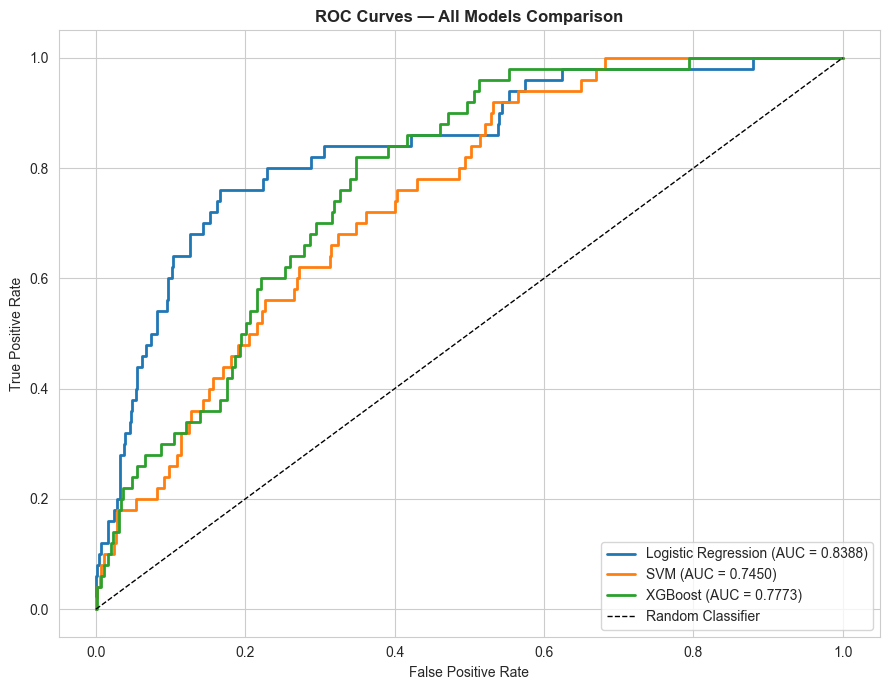

In [22]:
plt.figure(figsize=(9, 7))

for name, y_proba in [
    ("Logistic Regression", y_proba_lr),
    ("SVM", y_proba_svm),
    ("XGBoost", y_proba_xgb),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_value = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc_value:.4f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models Comparison", fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 9. Confusion Matrices Side by Side

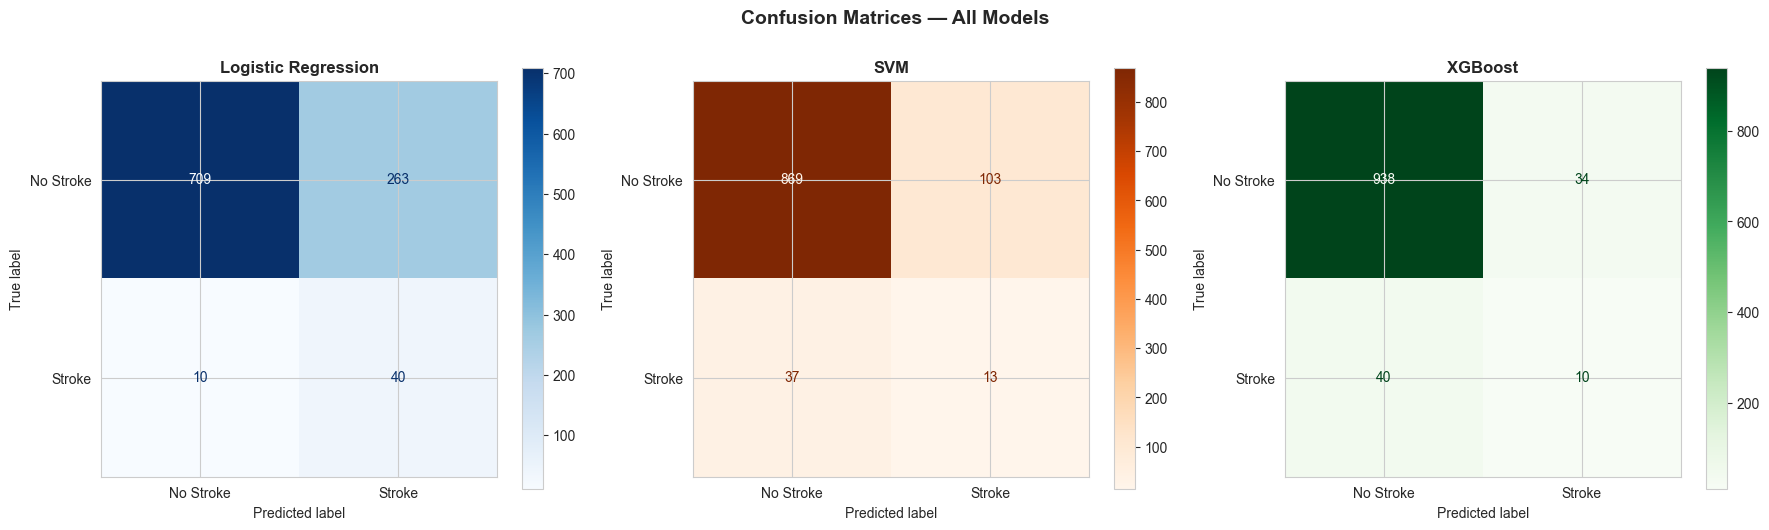

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_info = [
    ("Logistic Regression", y_pred_lr, "Blues"),
    ("SVM", y_pred_svm, "Oranges"),
    ("XGBoost", y_pred_xgb, "Greens"),
]

for ax, (name, y_pred, cmap) in zip(axes, models_info):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["No Stroke", "Stroke"],
        cmap=cmap,
        ax=ax
    )
    ax.set_title(name, fontweight="bold")

plt.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 10. Metric Comparison Bar Chart

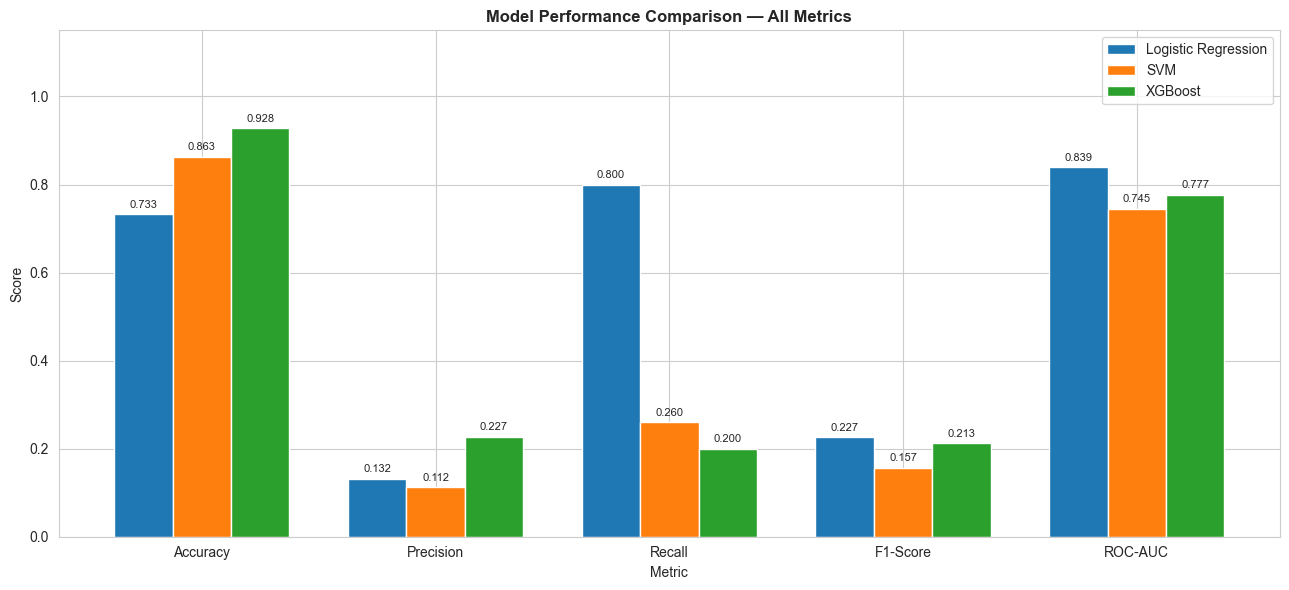

In [24]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

bars1 = ax.bar(x - width, [lr_results[m] for m in metrics], width, label="Logistic Regression")
bars2 = ax.bar(x, [svm_results[m] for m in metrics], width, label="SVM")
bars3 = ax.bar(x + width, [xgb_results[m] for m in metrics], width, label="XGBoost")

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison — All Metrics", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.legend()

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()
plt.show()

## 11. Training Time Comparison

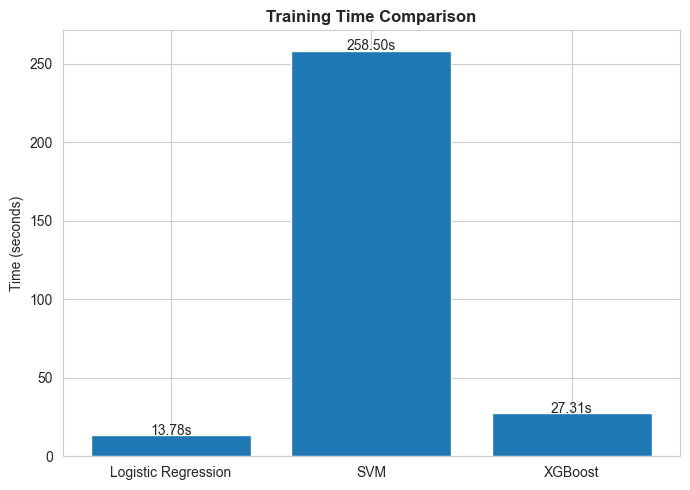

In [25]:
times = [lr_results["Train Time (s)"], svm_results["Train Time (s)"], xgb_results["Train Time (s)"]]

plt.figure(figsize=(7, 5))
bars = plt.bar(["Logistic Regression", "SVM", "XGBoost"], times)
plt.title("Training Time Comparison", fontweight="bold")
plt.ylabel("Time (seconds)")

for bar, value in zip(bars, times):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{value:.2f}s",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 12. Final Conclusion

In [26]:
best_model_name = results_df.loc[results_df["ROC-AUC"].idxmax(), "Model"]
best_auc = results_df["ROC-AUC"].max()
best_f1_model = results_df.loc[results_df["F1-Score"].idxmax(), "Model"]

print("=" * 70)
print("PHASE 2 — FINAL SUMMARY")
print("=" * 70)
print(f"Best ROC-AUC model : {best_model_name} ({best_auc:.4f})")
print(f"Best F1-Score model: {best_f1_model}")
print()
print(results_df.to_string(index=False))
print("=" * 70)

PHASE 2 — FINAL SUMMARY
Best ROC-AUC model : Logistic Regression (0.8388)
Best F1-Score model: Logistic Regression

              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Train Time (s)
Logistic Regression    0.7329     0.1320    0.80    0.2266   0.8388           13.78
                SVM    0.8630     0.1121    0.26    0.1566   0.7450          258.50
            XGBoost    0.9276     0.2273    0.20    0.2128   0.7773           27.31
